## MUSCL FDM Working

### 80 X 10

Grid: 80×10
Scheme: MUSCL
Time stepping: EULER
Printing every 20 steps
Plotting every 50 steps
Estimated total steps: ~19
Estimated runtime: ~0.2 seconds (based on 0.01s/step)
Step     20 | t=0.05065/0.2 | dt=0.00227 | ρ=0.5625 | u=0.1100 | p=0.5433 | speed=5.1 steps/s 
Step     40 | t=0.09522/0.2 | dt=0.00222 | ρ=0.5625 | u=0.2103 | p=0.5368 | speed=6.1 steps/s 
Step     60 | t=0.14003/0.2 | dt=0.00226 | ρ=0.5625 | u=0.3098 | p=0.5303 | speed=6.6 steps/s 
Step     80 | t=0.18522/0.2 | dt=0.00226 | ρ=0.5625 | u=0.4099 | p=0.5238 | speed=7.0 steps/s 
Completed in 12.29 seconds
Total steps: 87
Average speed: 7.1 steps/second

VALIDATION WITH EXACT SOD SOLUTION

L1 Errors at t=0.2:
  Density:  0.010267
  Velocity: 0.017255
  Pressure: 0.008911


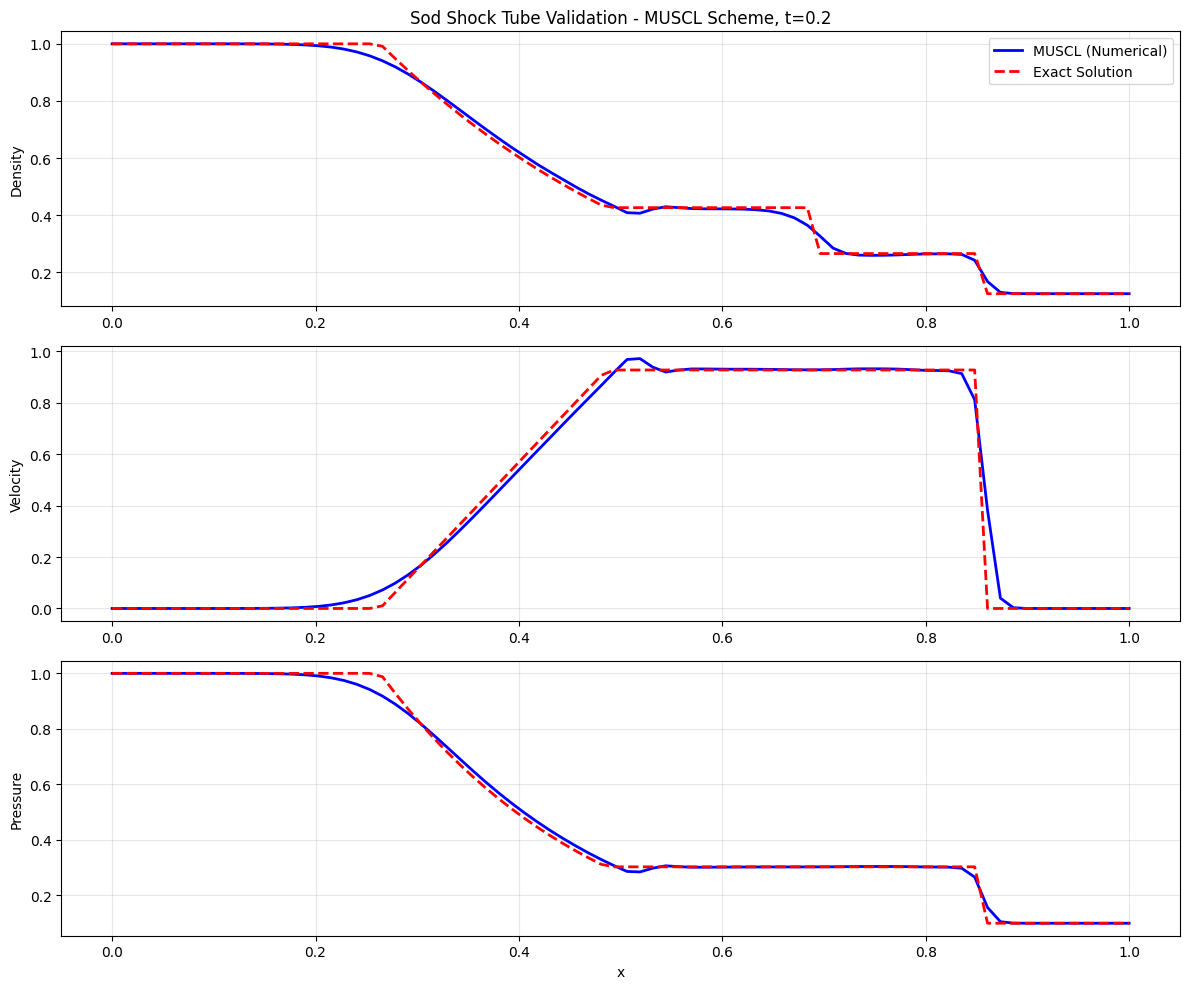


✓ Validation plot saved as 'validation.png'

GENERATING FINAL 2D VISUALIZATION


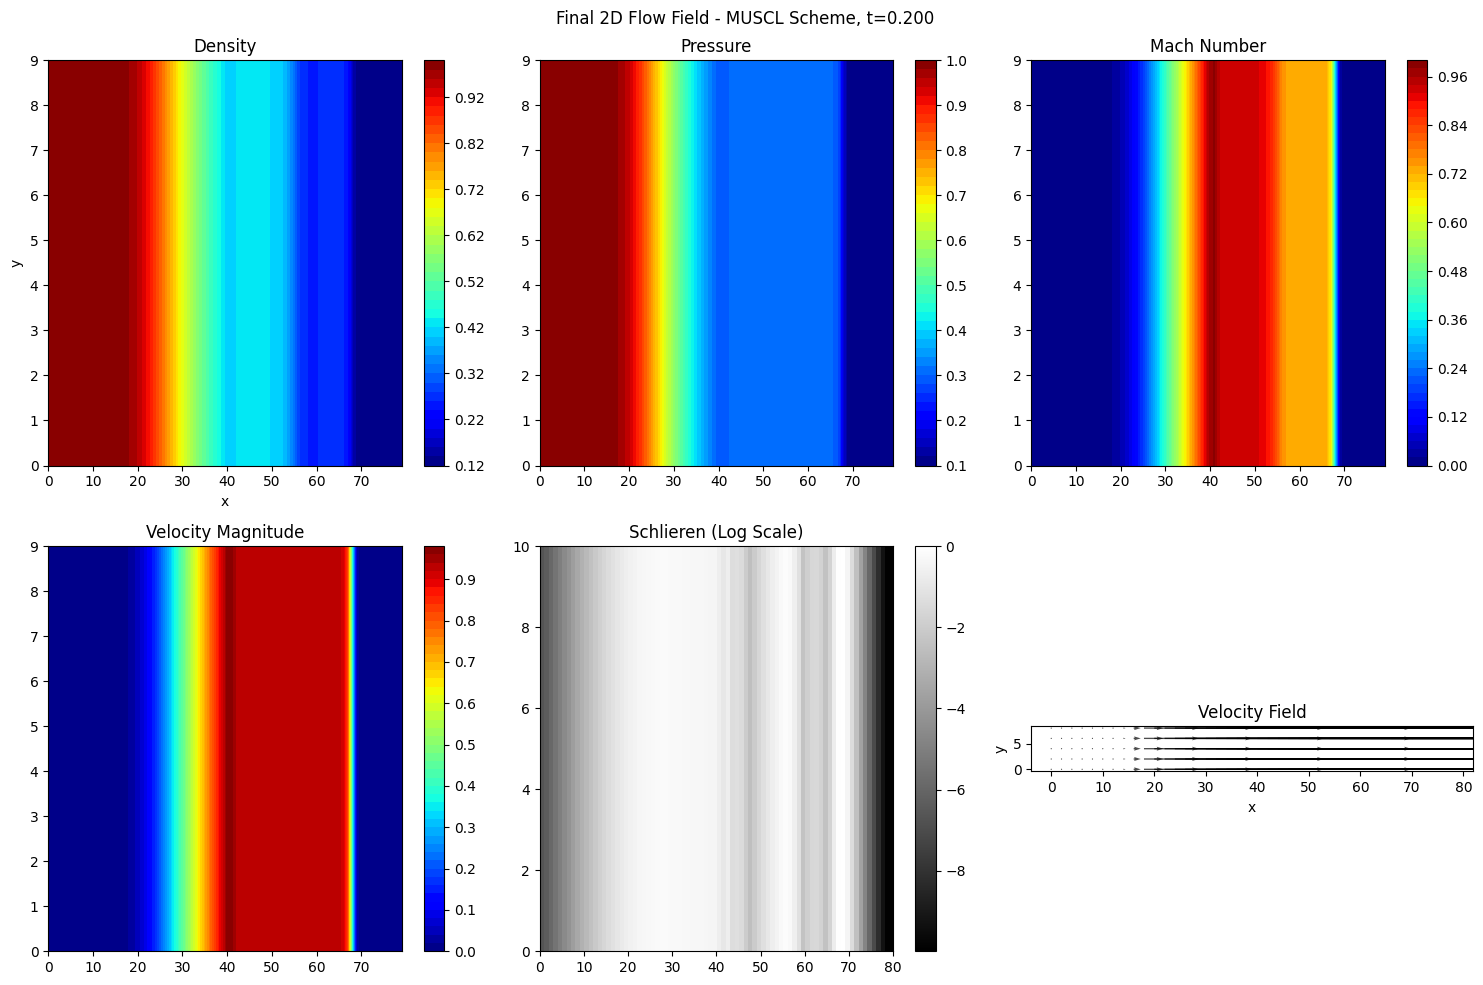


SIMULATION COMPLETE!
Files saved:
  - validation.png      (Comparison with exact solution)
  - final_fields.png    (2D contour plots)
  - centerline_data.txt (Numerical and exact data)

Grid: 80×10
Scheme: MUSCL
Time stepping: EULER
Final time: 0.2000
Total steps: 87
Runtime: 12.29 seconds


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from matplotlib.colors import LogNorm

# ============================================
# PARAMETERS
# ============================================
gamma = 1.4
NX, NY = 80, 10  # Your grid size
NG = 2  # Ghost cells

Nx, Ny = NX + 2*NG, NY + 2*NG
dx = 1.0 / NX
dy = 1.0 / NY

CFL = 0.4
t_final = 0.2
EPS = 1e-8

# ========== SCHEME SELECTION ==========
NUMERICAL_SCHEME = 'muscl'  # or 'central'
TIME_STEPPING = 'euler'  # or 'rk2'

# ========== PERFORMANCE OPTIMIZATIONS ==========
SHOW_LIVE_PLOTS = False  # Set to False for speed
PLOT_EVERY_N_STEPS = 50  # Plot less frequently for speed
PRINT_EVERY_N_STEPS = 20  # Print progress
USE_FASTER_PLOTTING = True  # Use simpler plots for speed

# ============================================
# INITIAL CONDITION
# ============================================

U = np.zeros((4, Nx, Ny))

for i in range(Nx):
    for j in range(Ny):
        if i < Nx//2:
            rho, u, v, p = 1.0, 0.0, 0.0, 1.0
        else:
            rho, u, v, p = 0.125, 0.0, 0.0, 0.1

        U[0,i,j] = rho
        U[1,i,j] = rho*u
        U[2,i,j] = rho*v
        U[3,i,j] = p/(gamma-1) + 0.5*rho*(u*u+v*v)

# ============================================
# BOUNDARY CONDITIONS
# ============================================

def apply_bc(U):
    U[:, :NG, :] = U[:, NG:NG+1, :]
    U[:, -NG:, :] = U[:, -NG-1:-NG, :]
    U[:, :, :NG] = U[:, :, NG:NG+1]
    U[:, :, -NG:] = U[:, :, -NG-1:-NG]

# ============================================
# PRIMITIVE VARIABLES
# ============================================

def cons_to_prim(U):
    rho = np.maximum(U[0], EPS)
    u = U[1] / rho
    v = U[2] / rho
    E = U[3]
    p = (gamma-1) * (E - 0.5*rho*(u*u + v*v))
    p = np.maximum(p, EPS)
    return rho, u, v, p

def prim_to_cons(rho, u, v, p):
    E = p/(gamma-1) + 0.5*rho*(u*u + v*v)
    return np.array([rho, rho*u, rho*v, E])

# ============================================
# HLLC RIEMANN SOLVER
# ============================================

def hllc_flux(UL, UR):
    rhoL = max(UL[0], EPS)
    uL = UL[1]/rhoL
    vL = UL[2]/rhoL
    pL = (gamma-1)*(UL[3] - 0.5*rhoL*(uL*uL + vL*vL))
    pL = max(pL, EPS)

    rhoR = max(UR[0], EPS)
    uR = UR[1]/rhoR
    vR = UR[2]/rhoR
    pR = (gamma-1)*(UR[3] - 0.5*rhoR*(uR*uR + vR*vR))
    pR = max(pR, EPS)

    cL = np.sqrt(gamma*pL/rhoL)
    cR = np.sqrt(gamma*pR/rhoR)

    rho_avg = np.sqrt(rhoL*rhoR)
    u_avg = (np.sqrt(rhoL)*uL + np.sqrt(rhoR)*uR) / (np.sqrt(rhoL) + np.sqrt(rhoR))
    c_avg = np.sqrt(gamma * (pL + pR) / (rhoL + rhoR))

    SL = min(uL - cL, u_avg - c_avg)
    SR = max(uR + cR, u_avg + c_avg)

    FL = np.array([rhoL*uL,
                   rhoL*uL*uL + pL,
                   rhoL*uL*vL,
                   uL*(UL[3] + pL)])

    FR = np.array([rhoR*uR,
                   rhoR*uR*uR + pR,
                   rhoR*uR*vR,
                   uR*(UR[3] + pR)])

    if SL >= 0:
        return FL
    elif SR <= 0:
        return FR
    else:
        return (SR*FL - SL*FR + SL*SR*(UR - UL)) / (SR - SL)

# ============================================
# MUSCL RECONSTRUCTION
# ============================================

def minmod(a, b):
    if a * b <= 0:
        return 0.0
    return np.sign(a) * min(abs(a), abs(b))

def muscl_reconstruct(f):
    N = len(f)
    fL = np.zeros(N+1)
    fR = np.zeros(N+1)

    for i in range(1, N-1):
        slope = minmod(f[i] - f[i-1], f[i+1] - f[i])
        fL[i] = f[i] + 0.5 * slope
        fR[i+1] = f[i+1] - 0.5 * slope

    fL[0] = f[0]
    fL[-1] = f[-1]
    fR[0] = f[0]
    fR[-1] = f[-1]

    return fL, fR

def reconstruct_interface(U_line):
    nvar, N = U_line.shape

    rho = np.zeros(N)
    u = np.zeros(N)
    v = np.zeros(N)
    p = np.zeros(N)

    for i in range(N):
        rho[i], u[i], v[i], p[i] = cons_to_prim(U_line[:, i])

    rho_L, rho_R = muscl_reconstruct(rho)
    u_L, u_R = muscl_reconstruct(u)
    v_L, v_R = muscl_reconstruct(v)
    p_L, p_R = muscl_reconstruct(p)

    UL = np.zeros((nvar, N+1))
    UR = np.zeros((nvar, N+1))

    for i in range(N+1):
        UL[:, i] = prim_to_cons(rho_L[i], u_L[i], v_L[i], p_L[i])
        UR[:, i] = prim_to_cons(rho_R[i], u_R[i], v_R[i], p_R[i])

    return UL, UR

# ============================================
# CENTRAL DIFFERENCE
# ============================================

def central_flux(U_line):
    nvar, N = U_line.shape
    flux = np.zeros((nvar, N+1))

    for i in range(1, N):
        flux[:, i] = hllc_flux(U_line[:, i-1], U_line[:, i])

    flux[:, 0] = flux[:, 1]
    flux[:, -1] = flux[:, -2]

    return flux

# ============================================
# RHS COMPUTATION (OPTIMIZED)
# ============================================

def compute_rhs(U):
    rhs = np.zeros_like(U)

    if NUMERICAL_SCHEME == 'central':
        # X-direction
        for j in range(NG, Ny-NG):
            U_line = U[:, :, j]
            flux = central_flux(U_line)
            for i in range(NG, Nx-NG):
                rhs[:, i, j] -= (flux[:, i+1] - flux[:, i]) / dx

        # Y-direction
        for i in range(NG, Nx-NG):
            U_line = U[:, i, :]
            flux = central_flux(U_line)
            for j in range(NG, Ny-NG):
                rhs[:, i, j] -= (flux[:, j+1] - flux[:, j]) / dy

    else:  # MUSCL
        # X-direction
        for j in range(NG, Ny-NG):
            U_line = U[:, :, j]
            UL, UR = reconstruct_interface(U_line)

            for i in range(NG, Nx-NG):
                F_right = hllc_flux(UL[:, i], UR[:, i+1])
                F_left = hllc_flux(UL[:, i-1], UR[:, i])
                rhs[:, i, j] -= (F_right - F_left) / dx

        # Y-direction
        for i in range(NG, Nx-NG):
            U_line = U[:, i, :]
            UL, UR = reconstruct_interface(U_line)

            for j in range(NG, Ny-NG):
                UL_y = UL.copy()
                UR_y = UR.copy()
                UL_y[1], UL_y[2] = UL_y[2], UL_y[1]
                UR_y[1], UR_y[2] = UR_y[2], UR_y[1]

                F_top = hllc_flux(UL_y[:, j], UR_y[:, j+1])
                F_bottom = hllc_flux(UL_y[:, j-1], UR_y[:, j])
                rhs[:, i, j] -= (F_top - F_bottom) / dy

    return rhs

# ============================================
# TIME STEPPING
# ============================================

def euler_step(U, dt):
    return U + dt * compute_rhs(U)

def rk2_step(U, dt):
    U1 = U + dt * compute_rhs(U)
    apply_bc(U1)
    return U + 0.5 * dt * (compute_rhs(U) + compute_rhs(U1))

# ============================================
# PLOTTING FUNCTIONS (OPTIMIZED)
# ============================================

def compute_mean_values(U):
    rho = U[0, NG:-NG, NG:-NG]
    u = U[1, NG:-NG, NG:-NG] / rho
    v = U[2, NG:-NG, NG:-NG] / rho
    p = (gamma-1)*(U[3, NG:-NG, NG:-NG] - 0.5*rho*(u*u + v*v))

    rho_mean = np.mean(rho)
    u_mean = np.mean(np.sqrt(u*u + v*v))
    p_mean = np.mean(p)

    return rho_mean, u_mean, p_mean

# ============================================
# EXACT SOLUTION FOR SOD SHOCK TUBE
# ============================================

def exact_sod(x, t, gamma=1.4):
    """Exact solution for Sod shock tube problem"""
    rhoL, uL, pL = 1.0, 0.0, 1.0
    rhoR, uR, pR = 0.125, 0.0, 0.1

    def f(p, rho, p_i):
        A = 2 / ((gamma + 1) * rho)
        B = (gamma - 1) / (gamma + 1) * p_i

        if p > p_i:  # shock
            return (p - p_i) * np.sqrt(A / (p + B))
        else:  # rarefaction
            return (2 * np.sqrt(gamma * p_i / rho) /
                    (gamma - 1)) * ((p / p_i)**((gamma - 1)/(2*gamma)) - 1)

    # Solve for p_star
    p = 0.5 * (pL + pR)
    for _ in range(50):
        fL = f(p, rhoL, pL)
        fR = f(p, rhoR, pR)
        func = fL + fR + uR - uL

        dp = 1e-6
        df = (f(p+dp, rhoL, pL) + f(p+dp, rhoR, pR) - fL - fR) / dp

        p -= func / df
        p = max(p, 1e-6)

    p_star = p
    u_star = 0.5 * (uL + uR + fR - fL)

    # Wave speeds
    cL = np.sqrt(gamma * pL / rhoL)
    cR = np.sqrt(gamma * pR / rhoR)

    SHL = uL - cL  # Left shock/rarefaction speed
    STL = u_star - np.sqrt(gamma * p_star / (rhoL * (p_star / pL)**(1/gamma)))  # Left contact
    SR = uR + cR * np.sqrt((gamma + 1)/(2*gamma) * (p_star/pR - 1) + 1)  # Right shock speed

    # Initialize arrays
    rho = np.zeros_like(x)
    u = np.zeros_like(x)
    p_out = np.zeros_like(x)

    for i in range(len(x)):
        xi = (x[i] - 0.5) / t  # Position relative to diaphragm at x=0.5

        if xi < SHL:
            # Left state
            rho[i], u[i], p_out[i] = rhoL, uL, pL

        elif xi <= STL:
            # Left rarefaction fan
            u_i = (2/(gamma+1)) * (cL + xi)
            c_i = cL - (gamma-1)/2 * (u_i - uL)
            rho[i] = rhoL * (c_i/cL)**(2/(gamma-1))
            u[i] = u_i
            p_out[i] = pL * (c_i/cL)**(2*gamma/(gamma-1))

        elif xi < u_star:
            # Left star region
            rho[i] = rhoL * (p_star/pL)**(1/gamma)
            u[i] = u_star
            p_out[i] = p_star

        elif xi <= SR:
            # Right star region
            rho[i] = rhoR * ((p_star/pR + (gamma-1)/(gamma+1)) /
                            ((gamma-1)/(gamma+1) * p_star/pR + 1))
            u[i] = u_star
            p_out[i] = p_star

        else:
            # Right state
            rho[i], u[i], p_out[i] = rhoR, uR, pR

    return rho, u, p_out

# Global figure for live plotting (fixes the warning)
fig_live = None
axes_live = None

def plot_live_fields(U, step, t):
    global fig_live, axes_live

    if fig_live is None:
        fig_live, axes_live = plt.subplots(2, 2, figsize=(10, 8))
        plt.ion()

    # Clear axes
    for ax in axes_live.flat:
        ax.clear()

    # Get data
    rho = U[0, NG:-NG, NG:-NG]
    u = U[1, NG:-NG, NG:-NG] / rho
    v = U[2, NG:-NG, NG:-NG] / rho
    p = (gamma-1)*(U[3, NG:-NG, NG:-NG] - 0.5*rho*(u*u + v*v))

    # Mach number
    c = np.sqrt(gamma * p / rho)
    Mach = np.sqrt(u*u + v*v) / c

    # Simple plots without colorbars for speed
    im1 = axes_live[0,0].imshow(rho.T, origin='lower', cmap='jet',
                                 extent=[0, NX, 0, NY], aspect='auto')
    axes_live[0,0].set_title(f'Density (t={t:.3f})')

    im2 = axes_live[0,1].imshow(p.T, origin='lower', cmap='jet',
                                 extent=[0, NX, 0, NY], aspect='auto')
    axes_live[0,1].set_title('Pressure')

    im3 = axes_live[1,0].imshow(Mach.T, origin='lower', cmap='jet',
                                 extent=[0, NX, 0, NY], aspect='auto')
    axes_live[1,0].set_title('Mach Number')

    # Schlieren
    gradx = np.gradient(rho, axis=0)
    grady = np.gradient(rho, axis=1)
    grad_mag = np.sqrt(gradx**2 + grady**2)
    schlieren = np.log10(grad_mag / np.max(grad_mag) + 1e-10)
    im4 = axes_live[1,1].imshow(schlieren.T, origin='lower', cmap='gray',
                                 extent=[0, NX, 0, NY], aspect='auto')
    axes_live[1,1].set_title('Schlieren')

    plt.suptitle(f'2D Flow - Step {step}, {NUMERICAL_SCHEME.upper()}')
    plt.tight_layout()
    plt.draw()
    plt.pause(0.01)

# ============================================
# MAIN SIMULATION LOOP
# ============================================

print(f"Grid: {NX}×{NY}")
print(f"Scheme: {NUMERICAL_SCHEME.upper()}")
print(f"Time stepping: {TIME_STEPPING.upper()}")
print(f"Printing every {PRINT_EVERY_N_STEPS} steps")
print(f"Plotting every {PLOT_EVERY_N_STEPS} steps")
print("="*50)

start_time = time.time()
t = 0
step = 0

# Estimate total steps
estimated_steps = int(t_final / (CFL * min(dx, dy) / 0.5))  # Rough estimate
print(f"Estimated total steps: ~{estimated_steps}")
print(f"Estimated runtime: ~{estimated_steps * 0.01:.1f} seconds (based on 0.01s/step)")
print("="*50)

while t < t_final:
    apply_bc(U)

    # Calculate time step
    rho = np.maximum(U[0], EPS)
    u = U[1]/rho
    v = U[2]/rho
    p = (gamma-1)*(U[3] - 0.5*rho*(u*u+v*v))
    p = np.maximum(p, EPS)
    c = np.sqrt(gamma*p/rho)

    max_speed = np.max(np.abs(u) + np.abs(v) + c)
    dt = CFL * min(dx, dy) / max_speed

    if t + dt > t_final:
        dt = t_final - t

    # Time stepping
    if TIME_STEPPING == 'euler':
        U_new = euler_step(U, dt)
    else:
        U_new = rk2_step(U, dt)

    apply_bc(U_new)
    U = U_new

    t += dt
    step += 1

    # Compute mean values
    rho_mean, u_mean, p_mean = compute_mean_values(U)

    # Print progress
    if step % PRINT_EVERY_N_STEPS == 0:
        elapsed = time.time() - start_time
        steps_per_sec = step / elapsed if elapsed > 0 else 0
        eta = (estimated_steps - step) / steps_per_sec if steps_per_sec > 0 else 0

        print(f"Step {step:6d} | t={t:.5f}/{t_final} | dt={dt:.5f} | "
              f"ρ={rho_mean:.4f} | u={u_mean:.4f} | p={p_mean:.4f} | "
              f"speed={steps_per_sec:.1f} steps/s ")

    # Live plotting (optimized)
    if SHOW_LIVE_PLOTS and step % PLOT_EVERY_N_STEPS == 0:
        plot_live_fields(U, step, t)

end_time = time.time()
print("="*50)
print(f"Completed in {end_time - start_time:.2f} seconds")
print(f"Total steps: {step}")
print(f"Average speed: {step/(end_time-start_time):.1f} steps/second")

# ============================================
# VALIDATION WITH EXACT SOLUTION
# ============================================

print("\n" + "="*50)
print("VALIDATION WITH EXACT SOD SOLUTION")
print("="*50)

# Extract centerline data for validation
j_mid = Ny // 2
rho_num = U[0, NG:-NG, j_mid]
u_num = U[1, NG:-NG, j_mid] / rho_num
p_num = (gamma-1)*(U[3, NG:-NG, j_mid] - 0.5*rho_num*u_num**2)

x = np.linspace(0, 1, NX)

# Compute exact solution
rho_ex, u_ex, p_ex = exact_sod(x, t_final, gamma)

# Compute L1 errors
L1_rho = np.mean(np.abs(rho_num - rho_ex))
L1_u = np.mean(np.abs(u_num - u_ex))
L1_p = np.mean(np.abs(p_num - p_ex))

print(f"\nL1 Errors at t={t_final}:")
print(f"  Density:  {L1_rho:.6f}")
print(f"  Velocity: {L1_u:.6f}")
print(f"  Pressure: {L1_p:.6f}")

# Create validation plot
plt.figure(figsize=(12, 10))

plt.subplot(3, 1, 1)
plt.plot(x, rho_num, 'b-', linewidth=2, label=f'{NUMERICAL_SCHEME.upper()} (Numerical)')
plt.plot(x, rho_ex, 'r--', linewidth=2, label='Exact Solution')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title(f'Sod Shock Tube Validation - {NUMERICAL_SCHEME.upper()} Scheme, t={t_final}')

plt.subplot(3, 1, 2)
plt.plot(x, u_num, 'b-', linewidth=2)
plt.plot(x, u_ex, 'r--', linewidth=2)
plt.ylabel('Velocity')
plt.grid(True, alpha=0.3)

plt.subplot(3, 1, 3)
plt.plot(x, p_num, 'b-', linewidth=2)
plt.plot(x, p_ex, 'r--', linewidth=2)
plt.ylabel('Pressure')
plt.xlabel('x')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('validation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Validation plot saved as 'validation.png'")

# ============================================
# FINAL 2D PLOTS (SAVED TO FILES)
# ============================================

print("\n" + "="*50)
print("GENERATING FINAL 2D VISUALIZATION")
print("="*50)

# Extract all 2D fields
rho_final = U[0, NG:-NG, NG:-NG]
u_final = U[1, NG:-NG, NG:-NG] / rho_final
v_final = U[2, NG:-NG, NG:-NG] / rho_final
p_final = (gamma-1)*(U[3, NG:-NG, NG:-NG] - 0.5*rho_final*(u_final*u_final + v_final*v_final))
c_final = np.sqrt(gamma * p_final / rho_final)
Mach_final = np.sqrt(u_final*u_final + v_final*v_final) / c_final
vel_mag = np.sqrt(u_final*u_final + v_final*v_final)

# Schlieren (density gradient visualization)
gradx = np.gradient(rho_final, axis=0)
grady = np.gradient(rho_final, axis=1)
grad_mag = np.sqrt(gradx**2 + grady**2)
schlieren = np.log10(grad_mag / np.max(grad_mag) + 1e-10)

# Create final figure with all 2D fields
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Density
im1 = axes[0,0].contourf(rho_final.T, levels=50, cmap='jet')
plt.colorbar(im1, ax=axes[0,0])
axes[0,0].set_title('Density')
axes[0,0].set_xlabel('x')
axes[0,0].set_ylabel('y')

# Pressure
im2 = axes[0,1].contourf(p_final.T, levels=50, cmap='jet')
plt.colorbar(im2, ax=axes[0,1])
axes[0,1].set_title('Pressure')

# Mach number
im3 = axes[0,2].contourf(Mach_final.T, levels=50, cmap='jet')
plt.colorbar(im3, ax=axes[0,2])
axes[0,2].set_title('Mach Number')

# Velocity magnitude
im4 = axes[1,0].contourf(vel_mag.T, levels=50, cmap='jet')
plt.colorbar(im4, ax=axes[1,0])
axes[1,0].set_title('Velocity Magnitude')

# Schlieren
im5 = axes[1,1].imshow(schlieren.T, origin='lower', cmap='gray',
                       extent=[0, NX, 0, NY], aspect='auto')
plt.colorbar(im5, ax=axes[1,1])
axes[1,1].set_title('Schlieren (Log Scale)')

# Velocity vectors (subsampled for clarity)
skip = max(1, NX//30, NY//30)
X, Y = np.meshgrid(range(NX), range(NY), indexing='ij')
axes[1,2].quiver(X[::skip, ::skip], Y[::skip, ::skip],
                u_final[::skip, ::skip], v_final[::skip, ::skip],
                scale=0.5, alpha=0.7, width=0.003)
axes[1,2].set_title('Velocity Field')
axes[1,2].set_xlabel('x')
axes[1,2].set_ylabel('y')
axes[1,2].set_aspect('equal')

plt.suptitle(f'Final 2D Flow Field - {NUMERICAL_SCHEME.upper()} Scheme, t={t:.3f}')
plt.tight_layout()
plt.savefig('final_fields.png', dpi=200, bbox_inches='tight')
plt.show()

# Save centerline data for post-processing
np.savetxt('centerline_data.txt',
           np.column_stack([x, rho_num, u_num, p_num, rho_ex, u_ex, p_ex]),
           header='x, density_num, velocity_num, pressure_num, density_exact, velocity_exact, pressure_exact')

print("\n" + "="*50)
print("SIMULATION COMPLETE!")
print("="*50)
print(f"Files saved:")
print(f"  - validation.png      (Comparison with exact solution)")
print(f"  - final_fields.png    (2D contour plots)")
print(f"  - centerline_data.txt (Numerical and exact data)")
print(f"\nGrid: {NX}×{NY}")
print(f"Scheme: {NUMERICAL_SCHEME.upper()}")
print(f"Time stepping: {TIME_STEPPING.upper()}")
print(f"Final time: {t:.4f}")
print(f"Total steps: {step}")
print(f"Runtime: {end_time - start_time:.2f} seconds")
print("="*50)

### 200 X 100

Grid: 200×100
Scheme: MUSCL
Time stepping: EULER
Printing every 20 steps
Plotting every 50 steps
Estimated total steps: ~50
Estimated runtime: ~0.5 seconds (based on 0.01s/step)
Step     20 | t=0.02026/0.2 | dt=0.00091 | ρ=0.5625 | u=0.0440 | p=0.5473 | speed=0.3 steps/s 
Step     40 | t=0.03809/0.2 | dt=0.00089 | ρ=0.5625 | u=0.0841 | p=0.5447 | speed=0.3 steps/s 
Step     60 | t=0.05601/0.2 | dt=0.00090 | ρ=0.5625 | u=0.1239 | p=0.5421 | speed=0.3 steps/s 
Step     80 | t=0.07409/0.2 | dt=0.00090 | ρ=0.5625 | u=0.1640 | p=0.5395 | speed=0.3 steps/s 
Step    100 | t=0.09216/0.2 | dt=0.00090 | ρ=0.5625 | u=0.2039 | p=0.5369 | speed=0.3 steps/s 
Step    120 | t=0.11029/0.2 | dt=0.00091 | ρ=0.5625 | u=0.2438 | p=0.5342 | speed=0.3 steps/s 
Step    140 | t=0.12843/0.2 | dt=0.00091 | ρ=0.5625 | u=0.2839 | p=0.5316 | speed=0.3 steps/s 
Step    160 | t=0.14659/0.2 | dt=0.00091 | ρ=0.5625 | u=0.3240 | p=0.5289 | speed=0.3 steps/s 
Step    180 | t=0.16475/0.2 | dt=0.00091 | ρ=0.5625 | u=0.3641

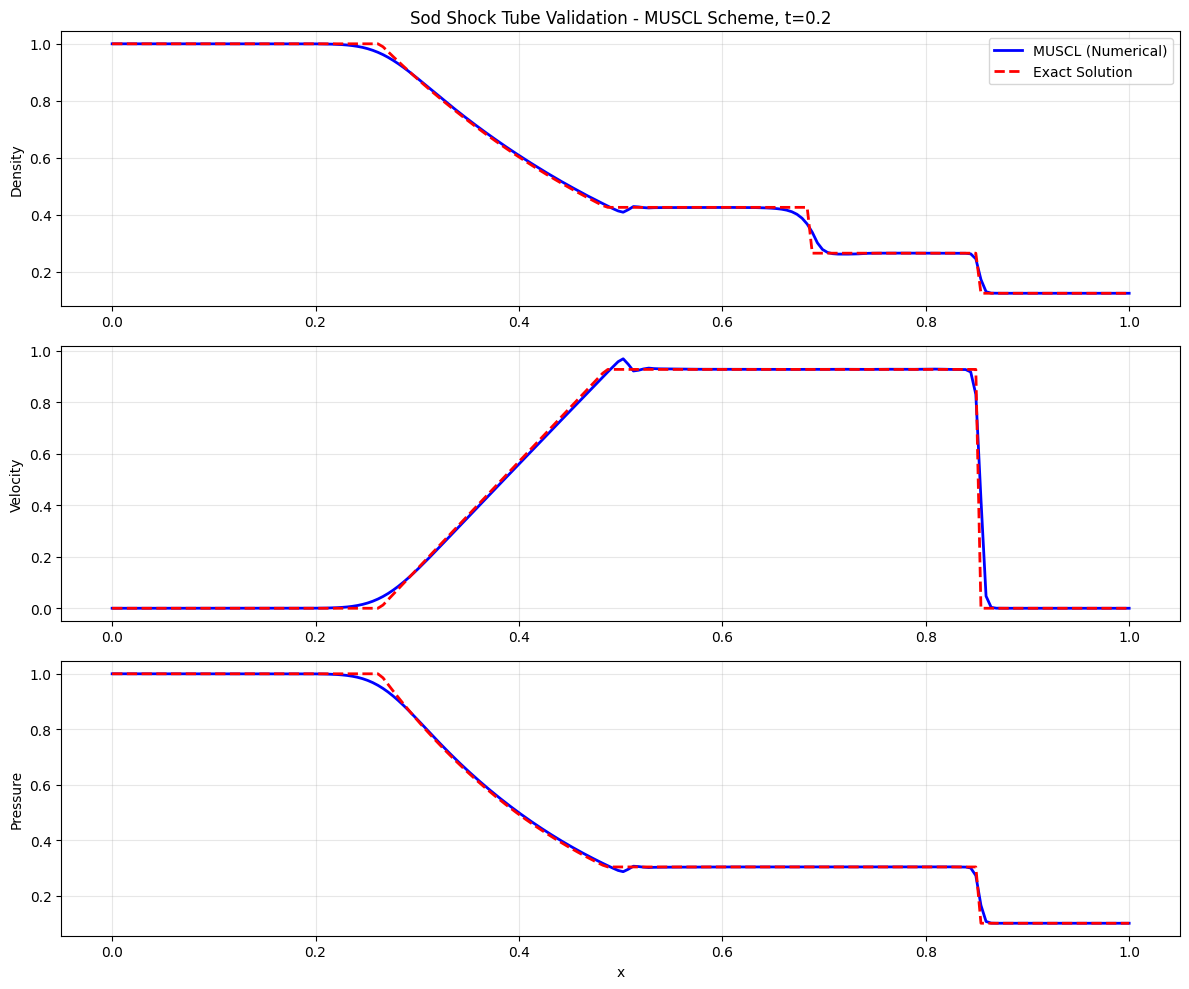


✓ Validation plot saved as 'validation.png'

GENERATING FINAL 2D VISUALIZATION


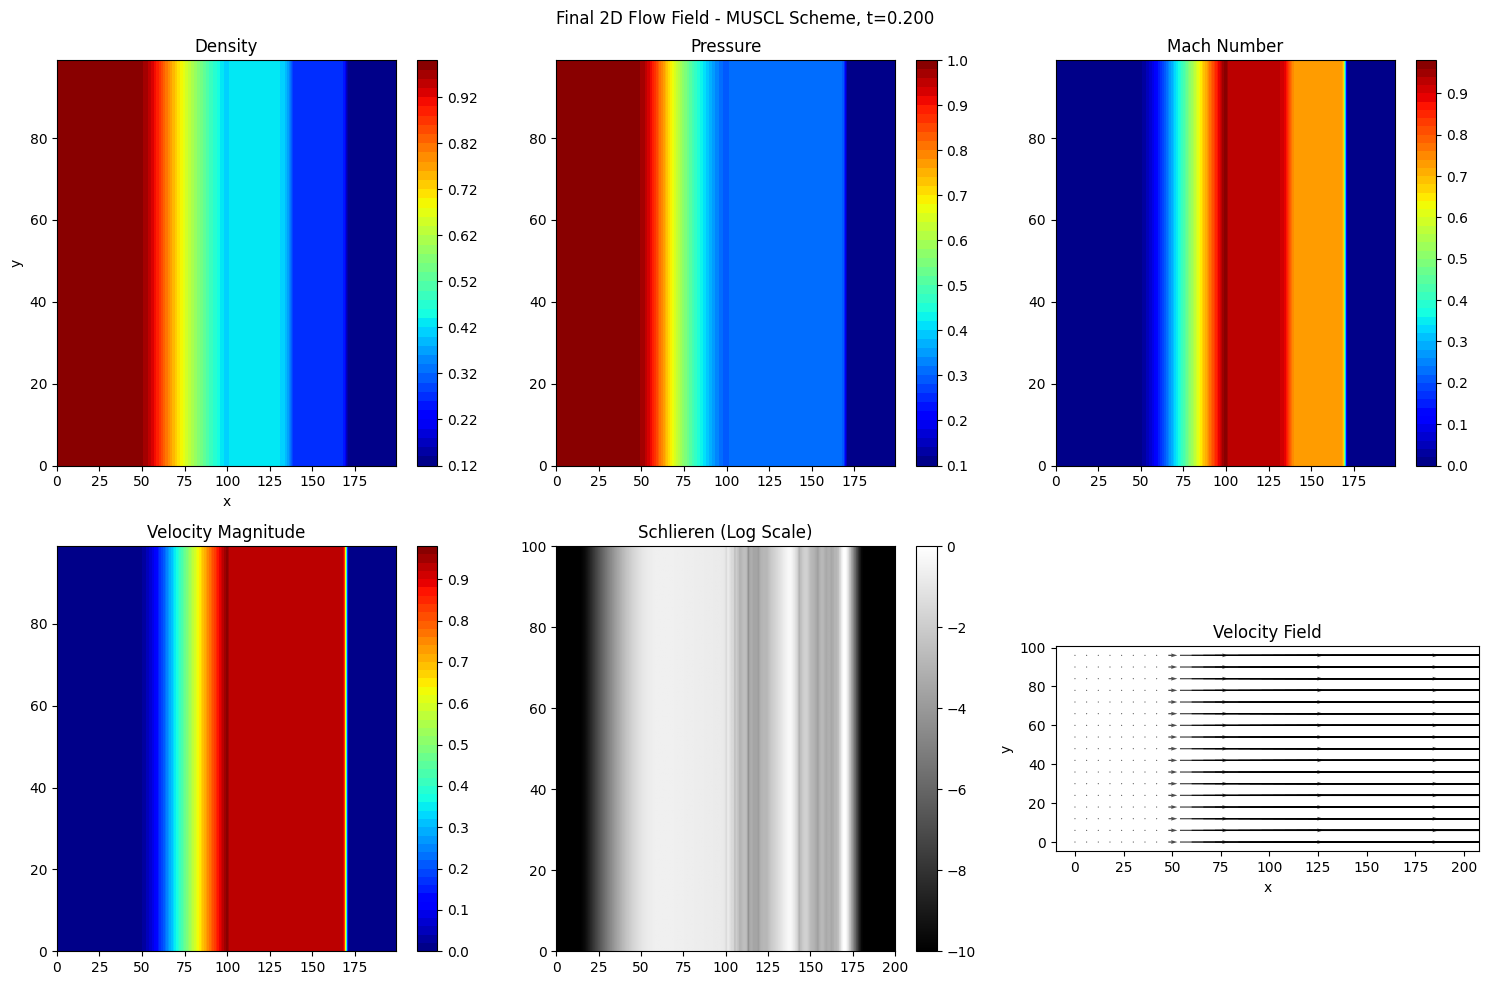


SIMULATION COMPLETE!
Files saved:
  - validation.png      (Comparison with exact solution)
  - final_fields.png    (2D contour plots)
  - centerline_data.txt (Numerical and exact data)

Grid: 200×100
Scheme: MUSCL
Time stepping: EULER
Final time: 0.2000
Total steps: 219
Runtime: 734.28 seconds


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from matplotlib.colors import LogNorm

# ============================================
# PARAMETERS
# ============================================
gamma = 1.4
NX, NY = 200, 100  # Your grid size
NG = 2  # Ghost cells

Nx, Ny = NX + 2*NG, NY + 2*NG
dx = 1.0 / NX
dy = 1.0 / NY

CFL = 0.4
t_final = 0.2
EPS = 1e-8

# ========== SCHEME SELECTION ==========
NUMERICAL_SCHEME = 'muscl'  # or 'central'
TIME_STEPPING = 'euler'  # or 'rk2'

# ========== PERFORMANCE OPTIMIZATIONS ==========
SHOW_LIVE_PLOTS = False  # Set to False for speed
PLOT_EVERY_N_STEPS = 50  # Plot less frequently for speed
PRINT_EVERY_N_STEPS = 20  # Print progress
USE_FASTER_PLOTTING = True  # Use simpler plots for speed

# ============================================
# INITIAL CONDITION
# ============================================

U = np.zeros((4, Nx, Ny))

for i in range(Nx):
    for j in range(Ny):
        if i < Nx//2:
            rho, u, v, p = 1.0, 0.0, 0.0, 1.0
        else:
            rho, u, v, p = 0.125, 0.0, 0.0, 0.1

        U[0,i,j] = rho
        U[1,i,j] = rho*u
        U[2,i,j] = rho*v
        U[3,i,j] = p/(gamma-1) + 0.5*rho*(u*u+v*v)

# ============================================
# BOUNDARY CONDITIONS
# ============================================

def apply_bc(U):
    U[:, :NG, :] = U[:, NG:NG+1, :]
    U[:, -NG:, :] = U[:, -NG-1:-NG, :]
    U[:, :, :NG] = U[:, :, NG:NG+1]
    U[:, :, -NG:] = U[:, :, -NG-1:-NG]

# ============================================
# PRIMITIVE VARIABLES
# ============================================

def cons_to_prim(U):
    rho = np.maximum(U[0], EPS)
    u = U[1] / rho
    v = U[2] / rho
    E = U[3]
    p = (gamma-1) * (E - 0.5*rho*(u*u + v*v))
    p = np.maximum(p, EPS)
    return rho, u, v, p

def prim_to_cons(rho, u, v, p):
    E = p/(gamma-1) + 0.5*rho*(u*u + v*v)
    return np.array([rho, rho*u, rho*v, E])

# ============================================
# HLLC RIEMANN SOLVER
# ============================================

def hllc_flux(UL, UR):
    rhoL = max(UL[0], EPS)
    uL = UL[1]/rhoL
    vL = UL[2]/rhoL
    pL = (gamma-1)*(UL[3] - 0.5*rhoL*(uL*uL + vL*vL))
    pL = max(pL, EPS)

    rhoR = max(UR[0], EPS)
    uR = UR[1]/rhoR
    vR = UR[2]/rhoR
    pR = (gamma-1)*(UR[3] - 0.5*rhoR*(uR*uR + vR*vR))
    pR = max(pR, EPS)

    cL = np.sqrt(gamma*pL/rhoL)
    cR = np.sqrt(gamma*pR/rhoR)

    rho_avg = np.sqrt(rhoL*rhoR)
    u_avg = (np.sqrt(rhoL)*uL + np.sqrt(rhoR)*uR) / (np.sqrt(rhoL) + np.sqrt(rhoR))
    c_avg = np.sqrt(gamma * (pL + pR) / (rhoL + rhoR))

    SL = min(uL - cL, u_avg - c_avg)
    SR = max(uR + cR, u_avg + c_avg)

    FL = np.array([rhoL*uL,
                   rhoL*uL*uL + pL,
                   rhoL*uL*vL,
                   uL*(UL[3] + pL)])

    FR = np.array([rhoR*uR,
                   rhoR*uR*uR + pR,
                   rhoR*uR*vR,
                   uR*(UR[3] + pR)])

    if SL >= 0:
        return FL
    elif SR <= 0:
        return FR
    else:
        return (SR*FL - SL*FR + SL*SR*(UR - UL)) / (SR - SL)

# ============================================
# MUSCL RECONSTRUCTION
# ============================================

def minmod(a, b):
    if a * b <= 0:
        return 0.0
    return np.sign(a) * min(abs(a), abs(b))

def muscl_reconstruct(f):
    N = len(f)
    fL = np.zeros(N+1)
    fR = np.zeros(N+1)

    for i in range(1, N-1):
        slope = minmod(f[i] - f[i-1], f[i+1] - f[i])
        fL[i] = f[i] + 0.5 * slope
        fR[i+1] = f[i+1] - 0.5 * slope

    fL[0] = f[0]
    fL[-1] = f[-1]
    fR[0] = f[0]
    fR[-1] = f[-1]

    return fL, fR

def reconstruct_interface(U_line):
    nvar, N = U_line.shape

    rho = np.zeros(N)
    u = np.zeros(N)
    v = np.zeros(N)
    p = np.zeros(N)

    for i in range(N):
        rho[i], u[i], v[i], p[i] = cons_to_prim(U_line[:, i])

    rho_L, rho_R = muscl_reconstruct(rho)
    u_L, u_R = muscl_reconstruct(u)
    v_L, v_R = muscl_reconstruct(v)
    p_L, p_R = muscl_reconstruct(p)

    UL = np.zeros((nvar, N+1))
    UR = np.zeros((nvar, N+1))

    for i in range(N+1):
        UL[:, i] = prim_to_cons(rho_L[i], u_L[i], v_L[i], p_L[i])
        UR[:, i] = prim_to_cons(rho_R[i], u_R[i], v_R[i], p_R[i])

    return UL, UR

# ============================================
# CENTRAL DIFFERENCE
# ============================================

def central_flux(U_line):
    nvar, N = U_line.shape
    flux = np.zeros((nvar, N+1))

    for i in range(1, N):
        flux[:, i] = hllc_flux(U_line[:, i-1], U_line[:, i])

    flux[:, 0] = flux[:, 1]
    flux[:, -1] = flux[:, -2]

    return flux

# ============================================
# RHS COMPUTATION (OPTIMIZED)
# ============================================

def compute_rhs(U):
    rhs = np.zeros_like(U)

    if NUMERICAL_SCHEME == 'central':
        # X-direction
        for j in range(NG, Ny-NG):
            U_line = U[:, :, j]
            flux = central_flux(U_line)
            for i in range(NG, Nx-NG):
                rhs[:, i, j] -= (flux[:, i+1] - flux[:, i]) / dx

        # Y-direction
        for i in range(NG, Nx-NG):
            U_line = U[:, i, :]
            flux = central_flux(U_line)
            for j in range(NG, Ny-NG):
                rhs[:, i, j] -= (flux[:, j+1] - flux[:, j]) / dy

    else:  # MUSCL
        # X-direction
        for j in range(NG, Ny-NG):
            U_line = U[:, :, j]
            UL, UR = reconstruct_interface(U_line)

            for i in range(NG, Nx-NG):
                F_right = hllc_flux(UL[:, i], UR[:, i+1])
                F_left = hllc_flux(UL[:, i-1], UR[:, i])
                rhs[:, i, j] -= (F_right - F_left) / dx

        # Y-direction
        for i in range(NG, Nx-NG):
            U_line = U[:, i, :]
            UL, UR = reconstruct_interface(U_line)

            for j in range(NG, Ny-NG):
                UL_y = UL.copy()
                UR_y = UR.copy()
                UL_y[1], UL_y[2] = UL_y[2], UL_y[1]
                UR_y[1], UR_y[2] = UR_y[2], UR_y[1]

                F_top = hllc_flux(UL_y[:, j], UR_y[:, j+1])
                F_bottom = hllc_flux(UL_y[:, j-1], UR_y[:, j])
                rhs[:, i, j] -= (F_top - F_bottom) / dy

    return rhs

# ============================================
# TIME STEPPING
# ============================================

def euler_step(U, dt):
    return U + dt * compute_rhs(U)

def rk2_step(U, dt):
    U1 = U + dt * compute_rhs(U)
    apply_bc(U1)
    return U + 0.5 * dt * (compute_rhs(U) + compute_rhs(U1))

# ============================================
# PLOTTING FUNCTIONS (OPTIMIZED)
# ============================================

def compute_mean_values(U):
    rho = U[0, NG:-NG, NG:-NG]
    u = U[1, NG:-NG, NG:-NG] / rho
    v = U[2, NG:-NG, NG:-NG] / rho
    p = (gamma-1)*(U[3, NG:-NG, NG:-NG] - 0.5*rho*(u*u + v*v))

    rho_mean = np.mean(rho)
    u_mean = np.mean(np.sqrt(u*u + v*v))
    p_mean = np.mean(p)

    return rho_mean, u_mean, p_mean

# ============================================
# EXACT SOLUTION FOR SOD SHOCK TUBE
# ============================================

def exact_sod(x, t, gamma=1.4):
    """Exact solution for Sod shock tube problem"""
    rhoL, uL, pL = 1.0, 0.0, 1.0
    rhoR, uR, pR = 0.125, 0.0, 0.1

    def f(p, rho, p_i):
        A = 2 / ((gamma + 1) * rho)
        B = (gamma - 1) / (gamma + 1) * p_i

        if p > p_i:  # shock
            return (p - p_i) * np.sqrt(A / (p + B))
        else:  # rarefaction
            return (2 * np.sqrt(gamma * p_i / rho) /
                    (gamma - 1)) * ((p / p_i)**((gamma - 1)/(2*gamma)) - 1)

    # Solve for p_star
    p = 0.5 * (pL + pR)
    for _ in range(50):
        fL = f(p, rhoL, pL)
        fR = f(p, rhoR, pR)
        func = fL + fR + uR - uL

        dp = 1e-6
        df = (f(p+dp, rhoL, pL) + f(p+dp, rhoR, pR) - fL - fR) / dp

        p -= func / df
        p = max(p, 1e-6)

    p_star = p
    u_star = 0.5 * (uL + uR + fR - fL)

    # Wave speeds
    cL = np.sqrt(gamma * pL / rhoL)
    cR = np.sqrt(gamma * pR / rhoR)

    SHL = uL - cL  # Left shock/rarefaction speed
    STL = u_star - np.sqrt(gamma * p_star / (rhoL * (p_star / pL)**(1/gamma)))  # Left contact
    SR = uR + cR * np.sqrt((gamma + 1)/(2*gamma) * (p_star/pR - 1) + 1)  # Right shock speed

    # Initialize arrays
    rho = np.zeros_like(x)
    u = np.zeros_like(x)
    p_out = np.zeros_like(x)

    for i in range(len(x)):
        xi = (x[i] - 0.5) / t  # Position relative to diaphragm at x=0.5

        if xi < SHL:
            # Left state
            rho[i], u[i], p_out[i] = rhoL, uL, pL

        elif xi <= STL:
            # Left rarefaction fan
            u_i = (2/(gamma+1)) * (cL + xi)
            c_i = cL - (gamma-1)/2 * (u_i - uL)
            rho[i] = rhoL * (c_i/cL)**(2/(gamma-1))
            u[i] = u_i
            p_out[i] = pL * (c_i/cL)**(2*gamma/(gamma-1))

        elif xi < u_star:
            # Left star region
            rho[i] = rhoL * (p_star/pL)**(1/gamma)
            u[i] = u_star
            p_out[i] = p_star

        elif xi <= SR:
            # Right star region
            rho[i] = rhoR * ((p_star/pR + (gamma-1)/(gamma+1)) /
                            ((gamma-1)/(gamma+1) * p_star/pR + 1))
            u[i] = u_star
            p_out[i] = p_star

        else:
            # Right state
            rho[i], u[i], p_out[i] = rhoR, uR, pR

    return rho, u, p_out

# Global figure for live plotting (fixes the warning)
fig_live = None
axes_live = None

def plot_live_fields(U, step, t):
    global fig_live, axes_live

    if fig_live is None:
        fig_live, axes_live = plt.subplots(2, 2, figsize=(10, 8))
        plt.ion()

    # Clear axes
    for ax in axes_live.flat:
        ax.clear()

    # Get data
    rho = U[0, NG:-NG, NG:-NG]
    u = U[1, NG:-NG, NG:-NG] / rho
    v = U[2, NG:-NG, NG:-NG] / rho
    p = (gamma-1)*(U[3, NG:-NG, NG:-NG] - 0.5*rho*(u*u + v*v))

    # Mach number
    c = np.sqrt(gamma * p / rho)
    Mach = np.sqrt(u*u + v*v) / c

    # Simple plots without colorbars for speed
    im1 = axes_live[0,0].imshow(rho.T, origin='lower', cmap='jet',
                                 extent=[0, NX, 0, NY], aspect='auto')
    axes_live[0,0].set_title(f'Density (t={t:.3f})')

    im2 = axes_live[0,1].imshow(p.T, origin='lower', cmap='jet',
                                 extent=[0, NX, 0, NY], aspect='auto')
    axes_live[0,1].set_title('Pressure')

    im3 = axes_live[1,0].imshow(Mach.T, origin='lower', cmap='jet',
                                 extent=[0, NX, 0, NY], aspect='auto')
    axes_live[1,0].set_title('Mach Number')

    # Schlieren
    gradx = np.gradient(rho, axis=0)
    grady = np.gradient(rho, axis=1)
    grad_mag = np.sqrt(gradx**2 + grady**2)
    schlieren = np.log10(grad_mag / np.max(grad_mag) + 1e-10)
    im4 = axes_live[1,1].imshow(schlieren.T, origin='lower', cmap='gray',
                                 extent=[0, NX, 0, NY], aspect='auto')
    axes_live[1,1].set_title('Schlieren')

    plt.suptitle(f'2D Flow - Step {step}, {NUMERICAL_SCHEME.upper()}')
    plt.tight_layout()
    plt.draw()
    plt.pause(0.01)

# ============================================
# MAIN SIMULATION LOOP
# ============================================

print(f"Grid: {NX}×{NY}")
print(f"Scheme: {NUMERICAL_SCHEME.upper()}")
print(f"Time stepping: {TIME_STEPPING.upper()}")
print(f"Printing every {PRINT_EVERY_N_STEPS} steps")
print(f"Plotting every {PLOT_EVERY_N_STEPS} steps")
print("="*50)

start_time = time.time()
t = 0
step = 0

# Estimate total steps
estimated_steps = int(t_final / (CFL * min(dx, dy) / 0.5))  # Rough estimate
print(f"Estimated total steps: ~{estimated_steps}")
print(f"Estimated runtime: ~{estimated_steps * 0.01:.1f} seconds (based on 0.01s/step)")
print("="*50)

while t < t_final:
    apply_bc(U)

    # Calculate time step
    rho = np.maximum(U[0], EPS)
    u = U[1]/rho
    v = U[2]/rho
    p = (gamma-1)*(U[3] - 0.5*rho*(u*u+v*v))
    p = np.maximum(p, EPS)
    c = np.sqrt(gamma*p/rho)

    max_speed = np.max(np.abs(u) + np.abs(v) + c)
    dt = CFL * min(dx, dy) / max_speed

    if t + dt > t_final:
        dt = t_final - t

    # Time stepping
    if TIME_STEPPING == 'euler':
        U_new = euler_step(U, dt)
    else:
        U_new = rk2_step(U, dt)

    apply_bc(U_new)
    U = U_new

    t += dt
    step += 1

    # Compute mean values
    rho_mean, u_mean, p_mean = compute_mean_values(U)

    # Print progress
    if step % PRINT_EVERY_N_STEPS == 0:
        elapsed = time.time() - start_time
        steps_per_sec = step / elapsed if elapsed > 0 else 0
        eta = (estimated_steps - step) / steps_per_sec if steps_per_sec > 0 else 0

        print(f"Step {step:6d} | t={t:.5f}/{t_final} | dt={dt:.5f} | "
              f"ρ={rho_mean:.4f} | u={u_mean:.4f} | p={p_mean:.4f} | "
              f"speed={steps_per_sec:.1f} steps/s ")

    # Live plotting (optimized)
    if SHOW_LIVE_PLOTS and step % PLOT_EVERY_N_STEPS == 0:
        plot_live_fields(U, step, t)

end_time = time.time()
print("="*50)
print(f"Completed in {end_time - start_time:.2f} seconds")
print(f"Total steps: {step}")
print(f"Average speed: {step/(end_time-start_time):.1f} steps/second")

# ============================================
# VALIDATION WITH EXACT SOLUTION
# ============================================

print("\n" + "="*50)
print("VALIDATION WITH EXACT SOD SOLUTION")
print("="*50)

# Extract centerline data for validation
j_mid = Ny // 2
rho_num = U[0, NG:-NG, j_mid]
u_num = U[1, NG:-NG, j_mid] / rho_num
p_num = (gamma-1)*(U[3, NG:-NG, j_mid] - 0.5*rho_num*u_num**2)

x = np.linspace(0, 1, NX)

# Compute exact solution
rho_ex, u_ex, p_ex = exact_sod(x, t_final, gamma)

# Compute L1 errors
L1_rho = np.mean(np.abs(rho_num - rho_ex))
L1_u = np.mean(np.abs(u_num - u_ex))
L1_p = np.mean(np.abs(p_num - p_ex))

print(f"\nL1 Errors at t={t_final}:")
print(f"  Density:  {L1_rho:.6f}")
print(f"  Velocity: {L1_u:.6f}")
print(f"  Pressure: {L1_p:.6f}")

# Create validation plot
plt.figure(figsize=(12, 10))

plt.subplot(3, 1, 1)
plt.plot(x, rho_num, 'b-', linewidth=2, label=f'{NUMERICAL_SCHEME.upper()} (Numerical)')
plt.plot(x, rho_ex, 'r--', linewidth=2, label='Exact Solution')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title(f'Sod Shock Tube Validation - {NUMERICAL_SCHEME.upper()} Scheme, t={t_final}')

plt.subplot(3, 1, 2)
plt.plot(x, u_num, 'b-', linewidth=2)
plt.plot(x, u_ex, 'r--', linewidth=2)
plt.ylabel('Velocity')
plt.grid(True, alpha=0.3)

plt.subplot(3, 1, 3)
plt.plot(x, p_num, 'b-', linewidth=2)
plt.plot(x, p_ex, 'r--', linewidth=2)
plt.ylabel('Pressure')
plt.xlabel('x')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('validation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Validation plot saved as 'validation.png'")

# ============================================
# FINAL 2D PLOTS (SAVED TO FILES)
# ============================================

print("\n" + "="*50)
print("GENERATING FINAL 2D VISUALIZATION")
print("="*50)

# Extract all 2D fields
rho_final = U[0, NG:-NG, NG:-NG]
u_final = U[1, NG:-NG, NG:-NG] / rho_final
v_final = U[2, NG:-NG, NG:-NG] / rho_final
p_final = (gamma-1)*(U[3, NG:-NG, NG:-NG] - 0.5*rho_final*(u_final*u_final + v_final*v_final))
c_final = np.sqrt(gamma * p_final / rho_final)
Mach_final = np.sqrt(u_final*u_final + v_final*v_final) / c_final
vel_mag = np.sqrt(u_final*u_final + v_final*v_final)

# Schlieren (density gradient visualization)
gradx = np.gradient(rho_final, axis=0)
grady = np.gradient(rho_final, axis=1)
grad_mag = np.sqrt(gradx**2 + grady**2)
schlieren = np.log10(grad_mag / np.max(grad_mag) + 1e-10)

# Create final figure with all 2D fields
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Density
im1 = axes[0,0].contourf(rho_final.T, levels=50, cmap='jet')
plt.colorbar(im1, ax=axes[0,0])
axes[0,0].set_title('Density')
axes[0,0].set_xlabel('x')
axes[0,0].set_ylabel('y')

# Pressure
im2 = axes[0,1].contourf(p_final.T, levels=50, cmap='jet')
plt.colorbar(im2, ax=axes[0,1])
axes[0,1].set_title('Pressure')

# Mach number
im3 = axes[0,2].contourf(Mach_final.T, levels=50, cmap='jet')
plt.colorbar(im3, ax=axes[0,2])
axes[0,2].set_title('Mach Number')

# Velocity magnitude
im4 = axes[1,0].contourf(vel_mag.T, levels=50, cmap='jet')
plt.colorbar(im4, ax=axes[1,0])
axes[1,0].set_title('Velocity Magnitude')

# Schlieren
im5 = axes[1,1].imshow(schlieren.T, origin='lower', cmap='gray',
                       extent=[0, NX, 0, NY], aspect='auto')
plt.colorbar(im5, ax=axes[1,1])
axes[1,1].set_title('Schlieren (Log Scale)')

# Velocity vectors (subsampled for clarity)
skip = max(1, NX//30, NY//30)
X, Y = np.meshgrid(range(NX), range(NY), indexing='ij')
axes[1,2].quiver(X[::skip, ::skip], Y[::skip, ::skip],
                u_final[::skip, ::skip], v_final[::skip, ::skip],
                scale=0.5, alpha=0.7, width=0.003)
axes[1,2].set_title('Velocity Field')
axes[1,2].set_xlabel('x')
axes[1,2].set_ylabel('y')
axes[1,2].set_aspect('equal')

plt.suptitle(f'Final 2D Flow Field - {NUMERICAL_SCHEME.upper()} Scheme, t={t:.3f}')
plt.tight_layout()
plt.savefig('final_fields.png', dpi=200, bbox_inches='tight')
plt.show()

# Save centerline data for post-processing
np.savetxt('centerline_data.txt',
           np.column_stack([x, rho_num, u_num, p_num, rho_ex, u_ex, p_ex]),
           header='x, density_num, velocity_num, pressure_num, density_exact, velocity_exact, pressure_exact')

print("\n" + "="*50)
print("SIMULATION COMPLETE!")
print("="*50)
print(f"Files saved:")
print(f"  - validation.png      (Comparison with exact solution)")
print(f"  - final_fields.png    (2D contour plots)")
print(f"  - centerline_data.txt (Numerical and exact data)")
print(f"\nGrid: {NX}×{NY}")
print(f"Scheme: {NUMERICAL_SCHEME.upper()}")
print(f"Time stepping: {TIME_STEPPING.upper()}")
print(f"Final time: {t:.4f}")
print(f"Total steps: {step}")
print(f"Runtime: {end_time - start_time:.2f} seconds")
print("="*50)

### 500 X 100

Grid: 500×100
Scheme: MUSCL
Time stepping: EULER
Printing every 20 steps
Plotting every 50 steps
Estimated total steps: ~125
Estimated runtime: ~1.2 seconds (based on 0.01s/step)
Step     20 | t=0.00810/0.2 | dt=0.00036 | ρ=0.5625 | u=0.0176 | p=0.5489 | speed=0.1 steps/s 
Step     40 | t=0.01524/0.2 | dt=0.00036 | ρ=0.5625 | u=0.0336 | p=0.5479 | speed=0.1 steps/s 
Step     60 | t=0.02241/0.2 | dt=0.00036 | ρ=0.5625 | u=0.0496 | p=0.5469 | speed=0.1 steps/s 
Step     80 | t=0.02964/0.2 | dt=0.00036 | ρ=0.5625 | u=0.0656 | p=0.5458 | speed=0.1 steps/s 
Step    100 | t=0.03687/0.2 | dt=0.00036 | ρ=0.5625 | u=0.0816 | p=0.5447 | speed=0.1 steps/s 
Step    120 | t=0.04412/0.2 | dt=0.00036 | ρ=0.5625 | u=0.0975 | p=0.5437 | speed=0.1 steps/s 
Step    140 | t=0.05137/0.2 | dt=0.00036 | ρ=0.5625 | u=0.1136 | p=0.5426 | speed=0.1 steps/s 
Step    160 | t=0.05863/0.2 | dt=0.00036 | ρ=0.5625 | u=0.1296 | p=0.5416 | speed=0.1 steps/s 
Step    180 | t=0.06590/0.2 | dt=0.00036 | ρ=0.5625 | u=0.145

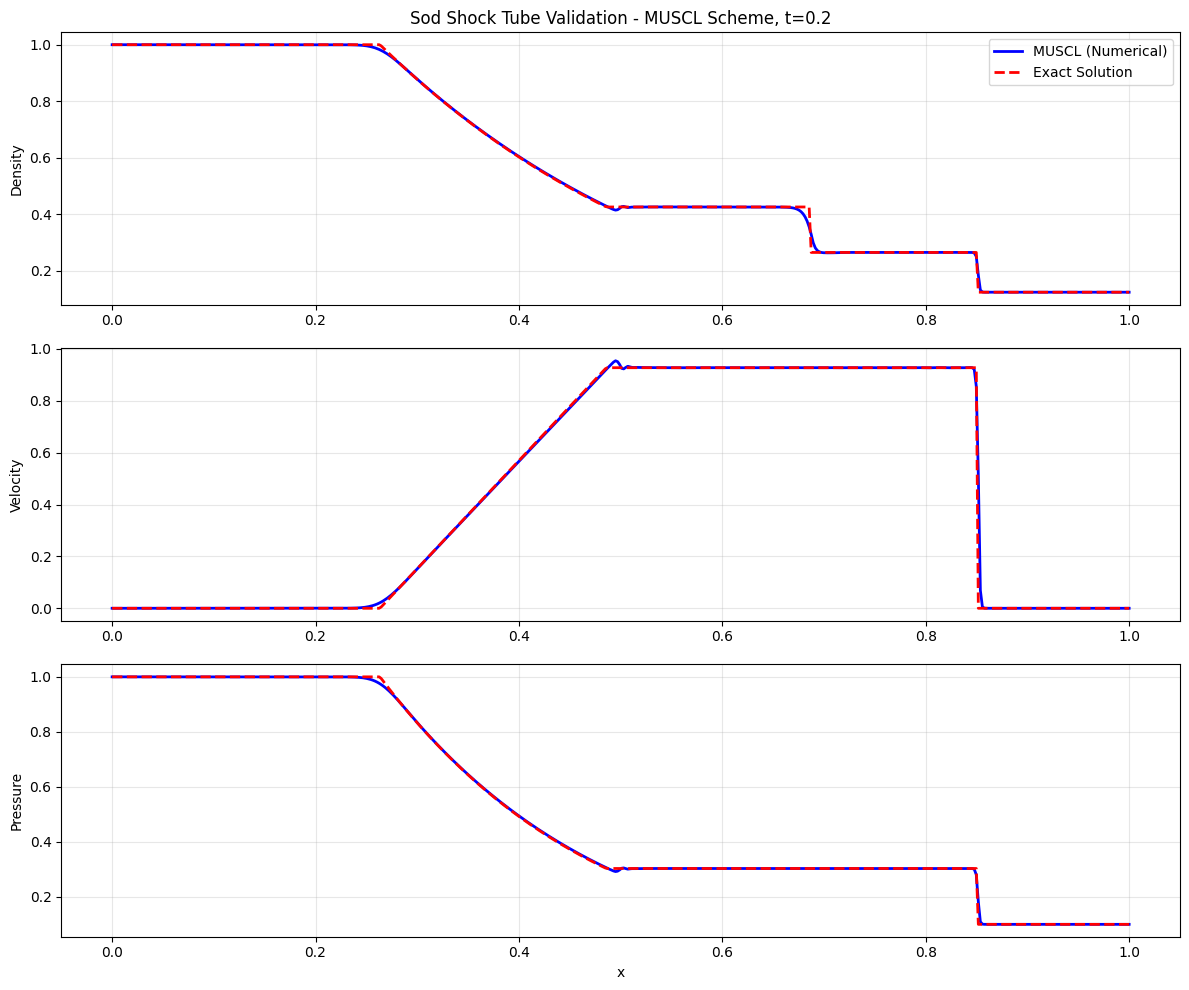


✓ Validation plot saved as 'validation.png'

GENERATING FINAL 2D VISUALIZATION


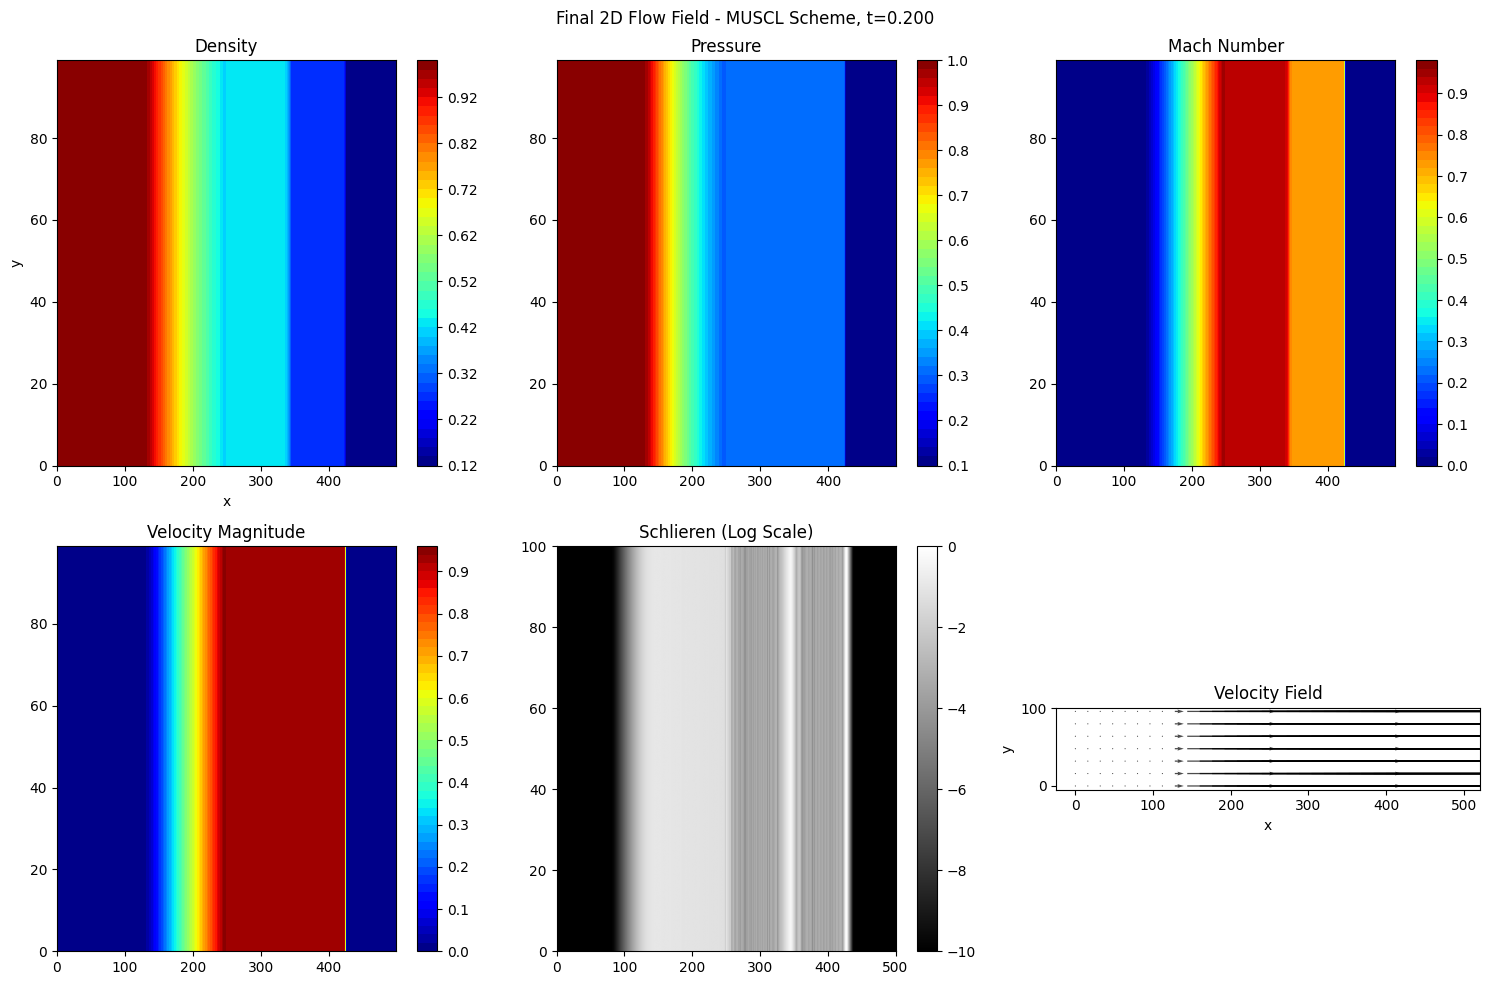


SIMULATION COMPLETE!
Files saved:
  - validation.png      (Comparison with exact solution)
  - final_fields.png    (2D contour plots)
  - centerline_data.txt (Numerical and exact data)

Grid: 500×100
Scheme: MUSCL
Time stepping: EULER
Final time: 0.2000
Total steps: 549
Runtime: 4423.51 seconds


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import time
from matplotlib.colors import LogNorm

# ============================================
# PARAMETERS
# ============================================
gamma = 1.4
NX, NY = 500, 100  # Your grid size
NG = 2  # Ghost cells

Nx, Ny = NX + 2*NG, NY + 2*NG
dx = 1.0 / NX
dy = 1.0 / NY

CFL = 0.4
t_final = 0.2
EPS = 1e-8

# ========== SCHEME SELECTION ==========
NUMERICAL_SCHEME = 'muscl'  # or 'central'
TIME_STEPPING = 'euler'  # or 'rk2'

# ========== PERFORMANCE OPTIMIZATIONS ==========
SHOW_LIVE_PLOTS = False  # Set to False for speed
PLOT_EVERY_N_STEPS = 50  # Plot less frequently for speed
PRINT_EVERY_N_STEPS = 20  # Print progress
USE_FASTER_PLOTTING = True  # Use simpler plots for speed

# ============================================
# INITIAL CONDITION
# ============================================

U = np.zeros((4, Nx, Ny))

for i in range(Nx):
    for j in range(Ny):
        if i < Nx//2:
            rho, u, v, p = 1.0, 0.0, 0.0, 1.0
        else:
            rho, u, v, p = 0.125, 0.0, 0.0, 0.1

        U[0,i,j] = rho
        U[1,i,j] = rho*u
        U[2,i,j] = rho*v
        U[3,i,j] = p/(gamma-1) + 0.5*rho*(u*u+v*v)

# ============================================
# BOUNDARY CONDITIONS
# ============================================

def apply_bc(U):
    U[:, :NG, :] = U[:, NG:NG+1, :]
    U[:, -NG:, :] = U[:, -NG-1:-NG, :]
    U[:, :, :NG] = U[:, :, NG:NG+1]
    U[:, :, -NG:] = U[:, :, -NG-1:-NG]

# ============================================
# PRIMITIVE VARIABLES
# ============================================

def cons_to_prim(U):
    rho = np.maximum(U[0], EPS)
    u = U[1] / rho
    v = U[2] / rho
    E = U[3]
    p = (gamma-1) * (E - 0.5*rho*(u*u + v*v))
    p = np.maximum(p, EPS)
    return rho, u, v, p

def prim_to_cons(rho, u, v, p):
    E = p/(gamma-1) + 0.5*rho*(u*u + v*v)
    return np.array([rho, rho*u, rho*v, E])

# ============================================
# HLLC RIEMANN SOLVER
# ============================================

def hllc_flux(UL, UR):
    rhoL = max(UL[0], EPS)
    uL = UL[1]/rhoL
    vL = UL[2]/rhoL
    pL = (gamma-1)*(UL[3] - 0.5*rhoL*(uL*uL + vL*vL))
    pL = max(pL, EPS)

    rhoR = max(UR[0], EPS)
    uR = UR[1]/rhoR
    vR = UR[2]/rhoR
    pR = (gamma-1)*(UR[3] - 0.5*rhoR*(uR*uR + vR*vR))
    pR = max(pR, EPS)

    cL = np.sqrt(gamma*pL/rhoL)
    cR = np.sqrt(gamma*pR/rhoR)

    rho_avg = np.sqrt(rhoL*rhoR)
    u_avg = (np.sqrt(rhoL)*uL + np.sqrt(rhoR)*uR) / (np.sqrt(rhoL) + np.sqrt(rhoR))
    c_avg = np.sqrt(gamma * (pL + pR) / (rhoL + rhoR))

    SL = min(uL - cL, u_avg - c_avg)
    SR = max(uR + cR, u_avg + c_avg)

    FL = np.array([rhoL*uL,
                   rhoL*uL*uL + pL,
                   rhoL*uL*vL,
                   uL*(UL[3] + pL)])

    FR = np.array([rhoR*uR,
                   rhoR*uR*uR + pR,
                   rhoR*uR*vR,
                   uR*(UR[3] + pR)])

    if SL >= 0:
        return FL
    elif SR <= 0:
        return FR
    else:
        return (SR*FL - SL*FR + SL*SR*(UR - UL)) / (SR - SL)

# ============================================
# MUSCL RECONSTRUCTION
# ============================================

def minmod(a, b):
    if a * b <= 0:
        return 0.0
    return np.sign(a) * min(abs(a), abs(b))

def muscl_reconstruct(f):
    N = len(f)
    fL = np.zeros(N+1)
    fR = np.zeros(N+1)

    for i in range(1, N-1):
        slope = minmod(f[i] - f[i-1], f[i+1] - f[i])
        fL[i] = f[i] + 0.5 * slope
        fR[i+1] = f[i+1] - 0.5 * slope

    fL[0] = f[0]
    fL[-1] = f[-1]
    fR[0] = f[0]
    fR[-1] = f[-1]

    return fL, fR

def reconstruct_interface(U_line):
    nvar, N = U_line.shape

    rho = np.zeros(N)
    u = np.zeros(N)
    v = np.zeros(N)
    p = np.zeros(N)

    for i in range(N):
        rho[i], u[i], v[i], p[i] = cons_to_prim(U_line[:, i])

    rho_L, rho_R = muscl_reconstruct(rho)
    u_L, u_R = muscl_reconstruct(u)
    v_L, v_R = muscl_reconstruct(v)
    p_L, p_R = muscl_reconstruct(p)

    UL = np.zeros((nvar, N+1))
    UR = np.zeros((nvar, N+1))

    for i in range(N+1):
        UL[:, i] = prim_to_cons(rho_L[i], u_L[i], v_L[i], p_L[i])
        UR[:, i] = prim_to_cons(rho_R[i], u_R[i], v_R[i], p_R[i])

    return UL, UR

# ============================================
# CENTRAL DIFFERENCE
# ============================================

def central_flux(U_line):
    nvar, N = U_line.shape
    flux = np.zeros((nvar, N+1))

    for i in range(1, N):
        flux[:, i] = hllc_flux(U_line[:, i-1], U_line[:, i])

    flux[:, 0] = flux[:, 1]
    flux[:, -1] = flux[:, -2]

    return flux

# ============================================
# RHS COMPUTATION (OPTIMIZED)
# ============================================

def compute_rhs(U):
    rhs = np.zeros_like(U)

    if NUMERICAL_SCHEME == 'central':
        # X-direction
        for j in range(NG, Ny-NG):
            U_line = U[:, :, j]
            flux = central_flux(U_line)
            for i in range(NG, Nx-NG):
                rhs[:, i, j] -= (flux[:, i+1] - flux[:, i]) / dx

        # Y-direction
        for i in range(NG, Nx-NG):
            U_line = U[:, i, :]
            flux = central_flux(U_line)
            for j in range(NG, Ny-NG):
                rhs[:, i, j] -= (flux[:, j+1] - flux[:, j]) / dy

    else:  # MUSCL
        # X-direction
        for j in range(NG, Ny-NG):
            U_line = U[:, :, j]
            UL, UR = reconstruct_interface(U_line)

            for i in range(NG, Nx-NG):
                F_right = hllc_flux(UL[:, i], UR[:, i+1])
                F_left = hllc_flux(UL[:, i-1], UR[:, i])
                rhs[:, i, j] -= (F_right - F_left) / dx

        # Y-direction
        for i in range(NG, Nx-NG):
            U_line = U[:, i, :]
            UL, UR = reconstruct_interface(U_line)

            for j in range(NG, Ny-NG):
                UL_y = UL.copy()
                UR_y = UR.copy()
                UL_y[1], UL_y[2] = UL_y[2], UL_y[1]
                UR_y[1], UR_y[2] = UR_y[2], UR_y[1]

                F_top = hllc_flux(UL_y[:, j], UR_y[:, j+1])
                F_bottom = hllc_flux(UL_y[:, j-1], UR_y[:, j])
                rhs[:, i, j] -= (F_top - F_bottom) / dy

    return rhs

# ============================================
# TIME STEPPING
# ============================================

def euler_step(U, dt):
    return U + dt * compute_rhs(U)

def rk2_step(U, dt):
    U1 = U + dt * compute_rhs(U)
    apply_bc(U1)
    return U + 0.5 * dt * (compute_rhs(U) + compute_rhs(U1))

# ============================================
# PLOTTING FUNCTIONS (OPTIMIZED)
# ============================================

def compute_mean_values(U):
    rho = U[0, NG:-NG, NG:-NG]
    u = U[1, NG:-NG, NG:-NG] / rho
    v = U[2, NG:-NG, NG:-NG] / rho
    p = (gamma-1)*(U[3, NG:-NG, NG:-NG] - 0.5*rho*(u*u + v*v))

    rho_mean = np.mean(rho)
    u_mean = np.mean(np.sqrt(u*u + v*v))
    p_mean = np.mean(p)

    return rho_mean, u_mean, p_mean

# ============================================
# EXACT SOLUTION FOR SOD SHOCK TUBE
# ============================================

def exact_sod(x, t, gamma=1.4):
    """Exact solution for Sod shock tube problem"""
    rhoL, uL, pL = 1.0, 0.0, 1.0
    rhoR, uR, pR = 0.125, 0.0, 0.1

    def f(p, rho, p_i):
        A = 2 / ((gamma + 1) * rho)
        B = (gamma - 1) / (gamma + 1) * p_i

        if p > p_i:  # shock
            return (p - p_i) * np.sqrt(A / (p + B))
        else:  # rarefaction
            return (2 * np.sqrt(gamma * p_i / rho) /
                    (gamma - 1)) * ((p / p_i)**((gamma - 1)/(2*gamma)) - 1)

    # Solve for p_star
    p = 0.5 * (pL + pR)
    for _ in range(50):
        fL = f(p, rhoL, pL)
        fR = f(p, rhoR, pR)
        func = fL + fR + uR - uL

        dp = 1e-6
        df = (f(p+dp, rhoL, pL) + f(p+dp, rhoR, pR) - fL - fR) / dp

        p -= func / df
        p = max(p, 1e-6)

    p_star = p
    u_star = 0.5 * (uL + uR + fR - fL)

    # Wave speeds
    cL = np.sqrt(gamma * pL / rhoL)
    cR = np.sqrt(gamma * pR / rhoR)

    SHL = uL - cL  # Left shock/rarefaction speed
    STL = u_star - np.sqrt(gamma * p_star / (rhoL * (p_star / pL)**(1/gamma)))  # Left contact
    SR = uR + cR * np.sqrt((gamma + 1)/(2*gamma) * (p_star/pR - 1) + 1)  # Right shock speed

    # Initialize arrays
    rho = np.zeros_like(x)
    u = np.zeros_like(x)
    p_out = np.zeros_like(x)

    for i in range(len(x)):
        xi = (x[i] - 0.5) / t  # Position relative to diaphragm at x=0.5

        if xi < SHL:
            # Left state
            rho[i], u[i], p_out[i] = rhoL, uL, pL

        elif xi <= STL:
            # Left rarefaction fan
            u_i = (2/(gamma+1)) * (cL + xi)
            c_i = cL - (gamma-1)/2 * (u_i - uL)
            rho[i] = rhoL * (c_i/cL)**(2/(gamma-1))
            u[i] = u_i
            p_out[i] = pL * (c_i/cL)**(2*gamma/(gamma-1))

        elif xi < u_star:
            # Left star region
            rho[i] = rhoL * (p_star/pL)**(1/gamma)
            u[i] = u_star
            p_out[i] = p_star

        elif xi <= SR:
            # Right star region
            rho[i] = rhoR * ((p_star/pR + (gamma-1)/(gamma+1)) /
                            ((gamma-1)/(gamma+1) * p_star/pR + 1))
            u[i] = u_star
            p_out[i] = p_star

        else:
            # Right state
            rho[i], u[i], p_out[i] = rhoR, uR, pR

    return rho, u, p_out

# Global figure for live plotting (fixes the warning)
fig_live = None
axes_live = None

def plot_live_fields(U, step, t):
    global fig_live, axes_live

    if fig_live is None:
        fig_live, axes_live = plt.subplots(2, 2, figsize=(10, 8))
        plt.ion()

    # Clear axes
    for ax in axes_live.flat:
        ax.clear()

    # Get data
    rho = U[0, NG:-NG, NG:-NG]
    u = U[1, NG:-NG, NG:-NG] / rho
    v = U[2, NG:-NG, NG:-NG] / rho
    p = (gamma-1)*(U[3, NG:-NG, NG:-NG] - 0.5*rho*(u*u + v*v))

    # Mach number
    c = np.sqrt(gamma * p / rho)
    Mach = np.sqrt(u*u + v*v) / c

    # Simple plots without colorbars for speed
    im1 = axes_live[0,0].imshow(rho.T, origin='lower', cmap='jet',
                                 extent=[0, NX, 0, NY], aspect='auto')
    axes_live[0,0].set_title(f'Density (t={t:.3f})')

    im2 = axes_live[0,1].imshow(p.T, origin='lower', cmap='jet',
                                 extent=[0, NX, 0, NY], aspect='auto')
    axes_live[0,1].set_title('Pressure')

    im3 = axes_live[1,0].imshow(Mach.T, origin='lower', cmap='jet',
                                 extent=[0, NX, 0, NY], aspect='auto')
    axes_live[1,0].set_title('Mach Number')

    # Schlieren
    gradx = np.gradient(rho, axis=0)
    grady = np.gradient(rho, axis=1)
    grad_mag = np.sqrt(gradx**2 + grady**2)
    schlieren = np.log10(grad_mag / np.max(grad_mag) + 1e-10)
    im4 = axes_live[1,1].imshow(schlieren.T, origin='lower', cmap='gray',
                                 extent=[0, NX, 0, NY], aspect='auto')
    axes_live[1,1].set_title('Schlieren')

    plt.suptitle(f'2D Flow - Step {step}, {NUMERICAL_SCHEME.upper()}')
    plt.tight_layout()
    plt.draw()
    plt.pause(0.01)

# ============================================
# MAIN SIMULATION LOOP
# ============================================

print(f"Grid: {NX}×{NY}")
print(f"Scheme: {NUMERICAL_SCHEME.upper()}")
print(f"Time stepping: {TIME_STEPPING.upper()}")
print(f"Printing every {PRINT_EVERY_N_STEPS} steps")
print(f"Plotting every {PLOT_EVERY_N_STEPS} steps")
print("="*50)

start_time = time.time()
t = 0
step = 0

# Estimate total steps
estimated_steps = int(t_final / (CFL * min(dx, dy) / 0.5))  # Rough estimate
print(f"Estimated total steps: ~{estimated_steps}")
print(f"Estimated runtime: ~{estimated_steps * 0.01:.1f} seconds (based on 0.01s/step)")
print("="*50)

while t < t_final:
    apply_bc(U)

    # Calculate time step
    rho = np.maximum(U[0], EPS)
    u = U[1]/rho
    v = U[2]/rho
    p = (gamma-1)*(U[3] - 0.5*rho*(u*u+v*v))
    p = np.maximum(p, EPS)
    c = np.sqrt(gamma*p/rho)

    max_speed = np.max(np.abs(u) + np.abs(v) + c)
    dt = CFL * min(dx, dy) / max_speed

    if t + dt > t_final:
        dt = t_final - t

    # Time stepping
    if TIME_STEPPING == 'euler':
        U_new = euler_step(U, dt)
    else:
        U_new = rk2_step(U, dt)

    apply_bc(U_new)
    U = U_new

    t += dt
    step += 1

    # Compute mean values
    rho_mean, u_mean, p_mean = compute_mean_values(U)

    # Print progress
    if step % PRINT_EVERY_N_STEPS == 0:
        elapsed = time.time() - start_time
        steps_per_sec = step / elapsed if elapsed > 0 else 0
        eta = (estimated_steps - step) / steps_per_sec if steps_per_sec > 0 else 0

        print(f"Step {step:6d} | t={t:.5f}/{t_final} | dt={dt:.5f} | "
              f"ρ={rho_mean:.4f} | u={u_mean:.4f} | p={p_mean:.4f} | "
              f"speed={steps_per_sec:.1f} steps/s ")

    # Live plotting (optimized)
    if SHOW_LIVE_PLOTS and step % PLOT_EVERY_N_STEPS == 0:
        plot_live_fields(U, step, t)

end_time = time.time()
print("="*50)
print(f"Completed in {end_time - start_time:.2f} seconds")
print(f"Total steps: {step}")
print(f"Average speed: {step/(end_time-start_time):.1f} steps/second")

# ============================================
# VALIDATION WITH EXACT SOLUTION
# ============================================

print("\n" + "="*50)
print("VALIDATION WITH EXACT SOD SOLUTION")
print("="*50)

# Extract centerline data for validation
j_mid = Ny // 2
rho_num = U[0, NG:-NG, j_mid]
u_num = U[1, NG:-NG, j_mid] / rho_num
p_num = (gamma-1)*(U[3, NG:-NG, j_mid] - 0.5*rho_num*u_num**2)

x = np.linspace(0, 1, NX)

# Compute exact solution
rho_ex, u_ex, p_ex = exact_sod(x, t_final, gamma)

# Compute L1 errors
L1_rho = np.mean(np.abs(rho_num - rho_ex))
L1_u = np.mean(np.abs(u_num - u_ex))
L1_p = np.mean(np.abs(p_num - p_ex))

print(f"\nL1 Errors at t={t_final}:")
print(f"  Density:  {L1_rho:.6f}")
print(f"  Velocity: {L1_u:.6f}")
print(f"  Pressure: {L1_p:.6f}")

# Create validation plot
plt.figure(figsize=(12, 10))

plt.subplot(3, 1, 1)
plt.plot(x, rho_num, 'b-', linewidth=2, label=f'{NUMERICAL_SCHEME.upper()} (Numerical)')
plt.plot(x, rho_ex, 'r--', linewidth=2, label='Exact Solution')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title(f'Sod Shock Tube Validation - {NUMERICAL_SCHEME.upper()} Scheme, t={t_final}')

plt.subplot(3, 1, 2)
plt.plot(x, u_num, 'b-', linewidth=2)
plt.plot(x, u_ex, 'r--', linewidth=2)
plt.ylabel('Velocity')
plt.grid(True, alpha=0.3)

plt.subplot(3, 1, 3)
plt.plot(x, p_num, 'b-', linewidth=2)
plt.plot(x, p_ex, 'r--', linewidth=2)
plt.ylabel('Pressure')
plt.xlabel('x')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('validation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Validation plot saved as 'validation.png'")

# ============================================
# FINAL 2D PLOTS (SAVED TO FILES)
# ============================================

print("\n" + "="*50)
print("GENERATING FINAL 2D VISUALIZATION")
print("="*50)

# Extract all 2D fields
rho_final = U[0, NG:-NG, NG:-NG]
u_final = U[1, NG:-NG, NG:-NG] / rho_final
v_final = U[2, NG:-NG, NG:-NG] / rho_final
p_final = (gamma-1)*(U[3, NG:-NG, NG:-NG] - 0.5*rho_final*(u_final*u_final + v_final*v_final))
c_final = np.sqrt(gamma * p_final / rho_final)
Mach_final = np.sqrt(u_final*u_final + v_final*v_final) / c_final
vel_mag = np.sqrt(u_final*u_final + v_final*v_final)

# Schlieren (density gradient visualization)
gradx = np.gradient(rho_final, axis=0)
grady = np.gradient(rho_final, axis=1)
grad_mag = np.sqrt(gradx**2 + grady**2)
schlieren = np.log10(grad_mag / np.max(grad_mag) + 1e-10)

# Create final figure with all 2D fields
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Density
im1 = axes[0,0].contourf(rho_final.T, levels=50, cmap='jet')
plt.colorbar(im1, ax=axes[0,0])
axes[0,0].set_title('Density')
axes[0,0].set_xlabel('x')
axes[0,0].set_ylabel('y')

# Pressure
im2 = axes[0,1].contourf(p_final.T, levels=50, cmap='jet')
plt.colorbar(im2, ax=axes[0,1])
axes[0,1].set_title('Pressure')

# Mach number
im3 = axes[0,2].contourf(Mach_final.T, levels=50, cmap='jet')
plt.colorbar(im3, ax=axes[0,2])
axes[0,2].set_title('Mach Number')

# Velocity magnitude
im4 = axes[1,0].contourf(vel_mag.T, levels=50, cmap='jet')
plt.colorbar(im4, ax=axes[1,0])
axes[1,0].set_title('Velocity Magnitude')

# Schlieren
im5 = axes[1,1].imshow(schlieren.T, origin='lower', cmap='gray',
                       extent=[0, NX, 0, NY], aspect='auto')
plt.colorbar(im5, ax=axes[1,1])
axes[1,1].set_title('Schlieren (Log Scale)')

# Velocity vectors (subsampled for clarity)
skip = max(1, NX//30, NY//30)
X, Y = np.meshgrid(range(NX), range(NY), indexing='ij')
axes[1,2].quiver(X[::skip, ::skip], Y[::skip, ::skip],
                u_final[::skip, ::skip], v_final[::skip, ::skip],
                scale=0.5, alpha=0.7, width=0.003)
axes[1,2].set_title('Velocity Field')
axes[1,2].set_xlabel('x')
axes[1,2].set_ylabel('y')
axes[1,2].set_aspect('equal')

plt.suptitle(f'Final 2D Flow Field - {NUMERICAL_SCHEME.upper()} Scheme, t={t:.3f}')
plt.tight_layout()
plt.savefig('final_fields.png', dpi=200, bbox_inches='tight')
plt.show()

# Save centerline data for post-processing
np.savetxt('centerline_data.txt',
           np.column_stack([x, rho_num, u_num, p_num, rho_ex, u_ex, p_ex]),
           header='x, density_num, velocity_num, pressure_num, density_exact, velocity_exact, pressure_exact')

print("\n" + "="*50)
print("SIMULATION COMPLETE!")
print("="*50)
print(f"Files saved:")
print(f"  - validation.png      (Comparison with exact solution)")
print(f"  - final_fields.png    (2D contour plots)")
print(f"  - centerline_data.txt (Numerical and exact data)")
print(f"\nGrid: {NX}×{NY}")
print(f"Scheme: {NUMERICAL_SCHEME.upper()}")
print(f"Time stepping: {TIME_STEPPING.upper()}")
print(f"Final time: {t:.4f}")
print(f"Total steps: {step}")
print(f"Runtime: {end_time - start_time:.2f} seconds")
print("="*50)